# **PROYECTO ETL, ENTREGA # 2: TRANSFORMACIÓN DE DATOS**

Joaquín Andrés Alarcón - 22500236, joaquin.alarcon@uao.edu.co

**Programa:** Maestría en inteligencia artificial y ciencia de datos.

### Notebook de prueba para las transformaciones

In [1]:
import etl
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_input = pd.read_csv("powerconsumption.csv", sep=",")
rename_columnas = {
        "Datetime": "datetime",
        "Temperature": "temperature",
        "Humidity": "humidity",
        "WindSpeed": "wind_speed",
        "GeneralDiffuseFlows": "general_diffuse_flows",
        "DiffuseFlows": "diffuse_flows",
        "PowerConsumption_Zone1": "power_consumption_zone1",
        "PowerConsumption_Zone2": "power_consumption_zone2",
        "PowerConsumption_Zone3": "power_consumption_zone3"
    }
file_input.rename(columns=rename_columnas, inplace=True)

In [5]:
# Veamos el encabezado del dataset
file_input.head(10)

,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,power_consumption_zone1,power_consumption_zone2,power_consumption_zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964
5,1/1/2017 0:50,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048
6,1/1/2017 1:00,5.641,77.7,0.080,0.048,0.096,25998.98734,16993.31307,17945.06024
7,1/1/2017 1:10,5.496,78.2,0.085,0.055,0.093,25446.07595,16661.39818,17459.27711
8,1/1/2017 1:20,5.678,78.1,0.081,0.066,0.141,24777.72152,16227.35562,17025.54217
9,1/1/2017 1:30,5.491,77.3,0.082,0.062,0.111,24279.49367,15939.20973,16794.21687


#### 1. Iniciemos con revisar si hay datos nulos, faltantes o repetidos, así como conocer el formato de las variables

In [6]:
file_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   datetime                 52416 non-null  object 
 1   temperature              52416 non-null  float64
 2   humidity                 52416 non-null  float64
 3   wind_speed               52416 non-null  float64
 4   general_diffuse_flows    52416 non-null  float64
 5   diffuse_flows            52416 non-null  float64
 6   power_consumption_zone1  52416 non-null  float64
 7   power_consumption_zone2  52416 non-null  float64
 8   power_consumption_zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


Hay que ajustar el formato de la fecha pues está tomándolo como un objeto, vamos a pasarlo  fecha para facilitar una transformación posterior

In [7]:
file_input['datetime'] = pd.to_datetime(file_input['datetime'])
file_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   datetime                 52416 non-null  datetime64[ns]
 1   temperature              52416 non-null  float64       
 2   humidity                 52416 non-null  float64       
 3   wind_speed               52416 non-null  float64       
 4   general_diffuse_flows    52416 non-null  float64       
 5   diffuse_flows            52416 non-null  float64       
 6   power_consumption_zone1  52416 non-null  float64       
 7   power_consumption_zone2  52416 non-null  float64       
 8   power_consumption_zone3  52416 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB


datetime                   0
temperature                0
humidity                   0
wind_speed                 0
general_diffuse_flows      0
diffuse_flows              0
power_consumption_zone1    0
power_consumption_zone2    0
power_consumption_zone3    0
dtype: int64


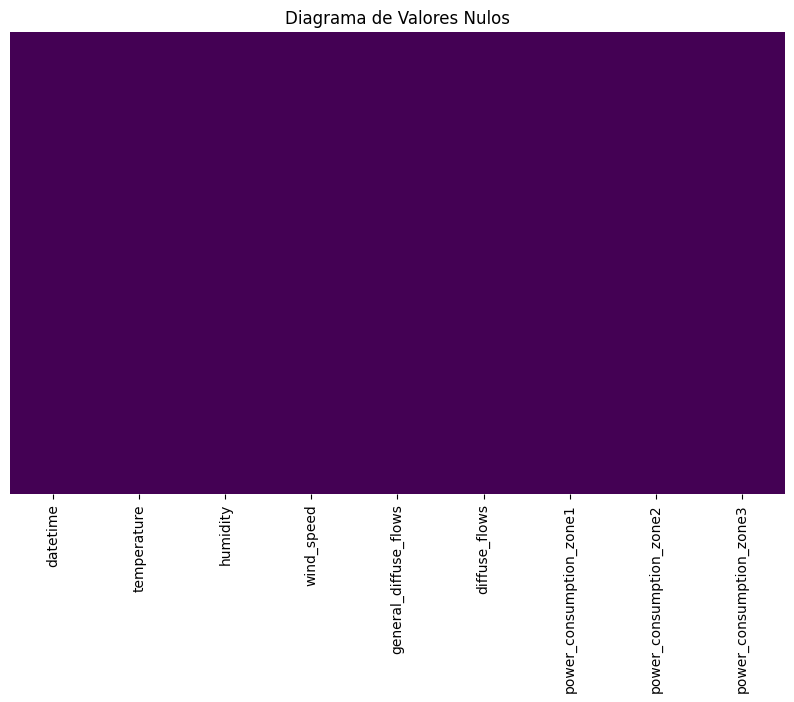

In [8]:
# Vamos a validar que no hay valores nulos
print(file_input.isnull().sum())
plt.figure(figsize=(10, 6))
sns.heatmap(file_input.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Diagrama de Valores Nulos")
plt.show()

In [9]:
file_input.isnull().sum()

datetime                   0
temperature                0
humidity                   0
wind_speed                 0
general_diffuse_flows      0
diffuse_flows              0
power_consumption_zone1    0
power_consumption_zone2    0
power_consumption_zone3    0
dtype: int64

No hay valores nulos ni faltantes

In [10]:
file_input['datetime'].value_counts()[file_input['datetime'].value_counts() > 1]


Series([], Name: count, dtype: int64)

No hay valores repetidos

No hay valores nulos ni vacíos en las celdas, vamos a hacer un pequeño análisis sobre la cantidad de datos que deberían haber, el año 2017 no fue bisiesto es decir fueron 365 días, cada día tiene 24 horas y las muestras están cada 10 minutos, es decir, 6 muestras por hora, por lo que:

In [11]:
print("El número de muestras esperadas son:"+str(365*24*6))
print("La cantidad de datos del dataset es: "+str(len(file_input)))
print("Diferencia: "+str(365*24*6-len(file_input)))

El número de muestras esperadas son:52560
La cantidad de datos del dataset es: 52416
Diferencia: 144


Al revisar el dataset encontramos que no hay datos para el 31 de diciembre, como no es hueco en la serie de tiempo que genere una discontinuidad, podemos trabajar con los datos existentes sin imponer una tendencia y de esta manera contar con los datos puros.

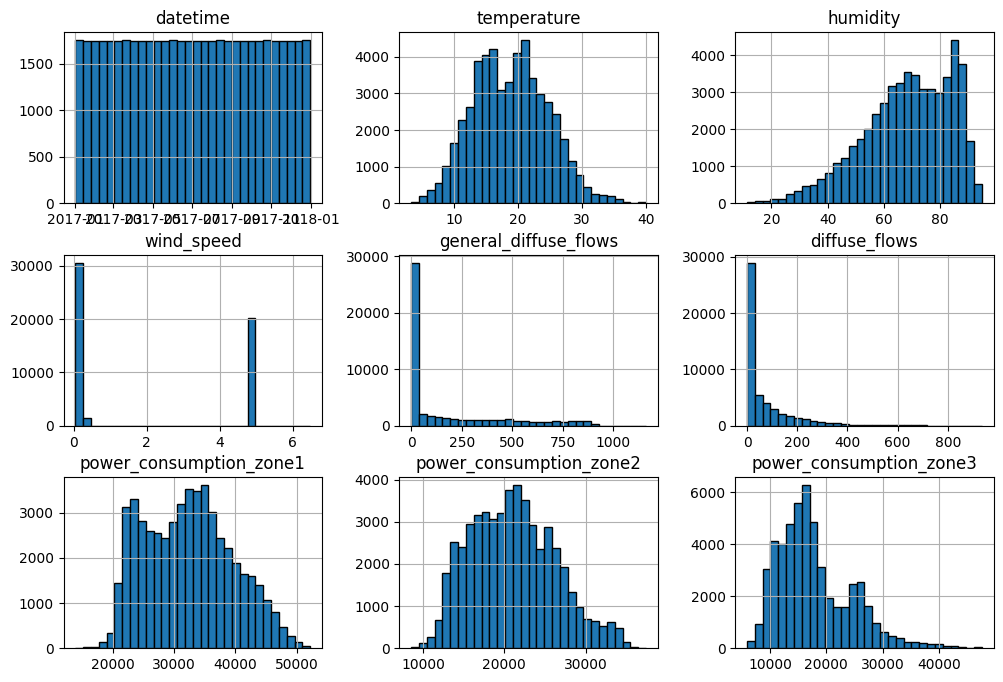

In [12]:
file_input.hist(figsize=(12, 8), bins=30, edgecolor="black")
plt.show()

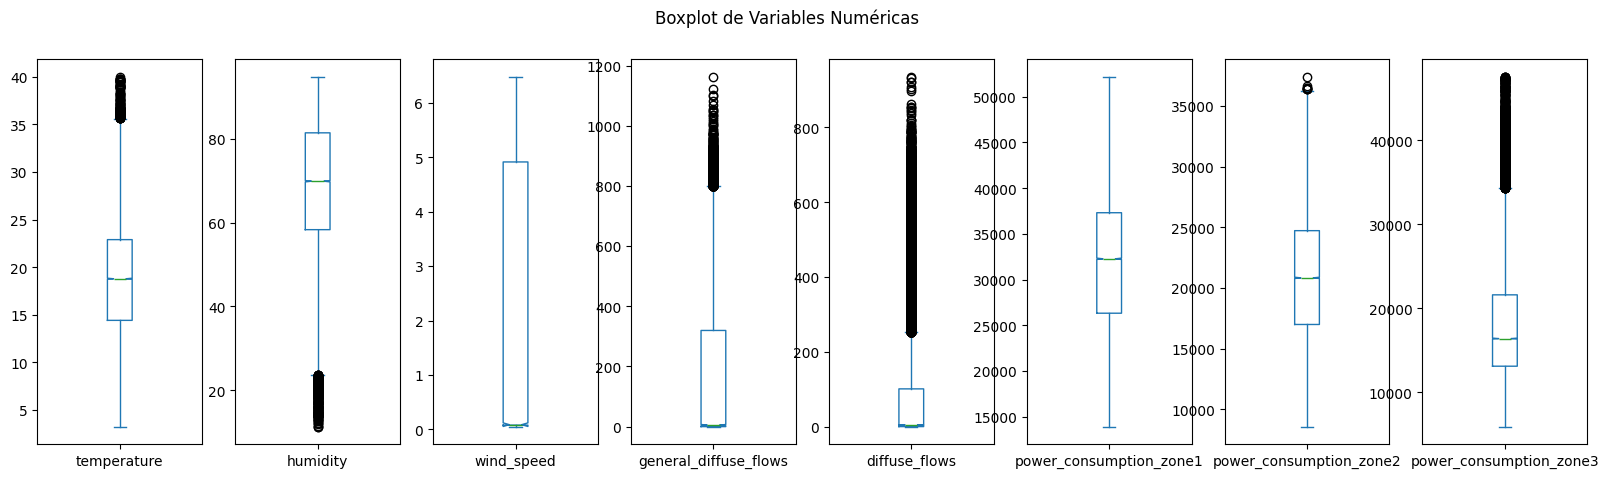

In [13]:
# Boxplot de cada variable numérica
file_input.plot(kind="box", subplots=True, layout=(1, len(file_input.select_dtypes(include=['number']).columns)),
        figsize=(20, 5), vert=True, notch=True)
plt.suptitle("Boxplot de Variables Numéricas")
plt.show()

Ahora generaremos la matriz de correlación para las diferentes variables actuales, con el fin de facilitar las decisiones siguientes sobre las transformaciones

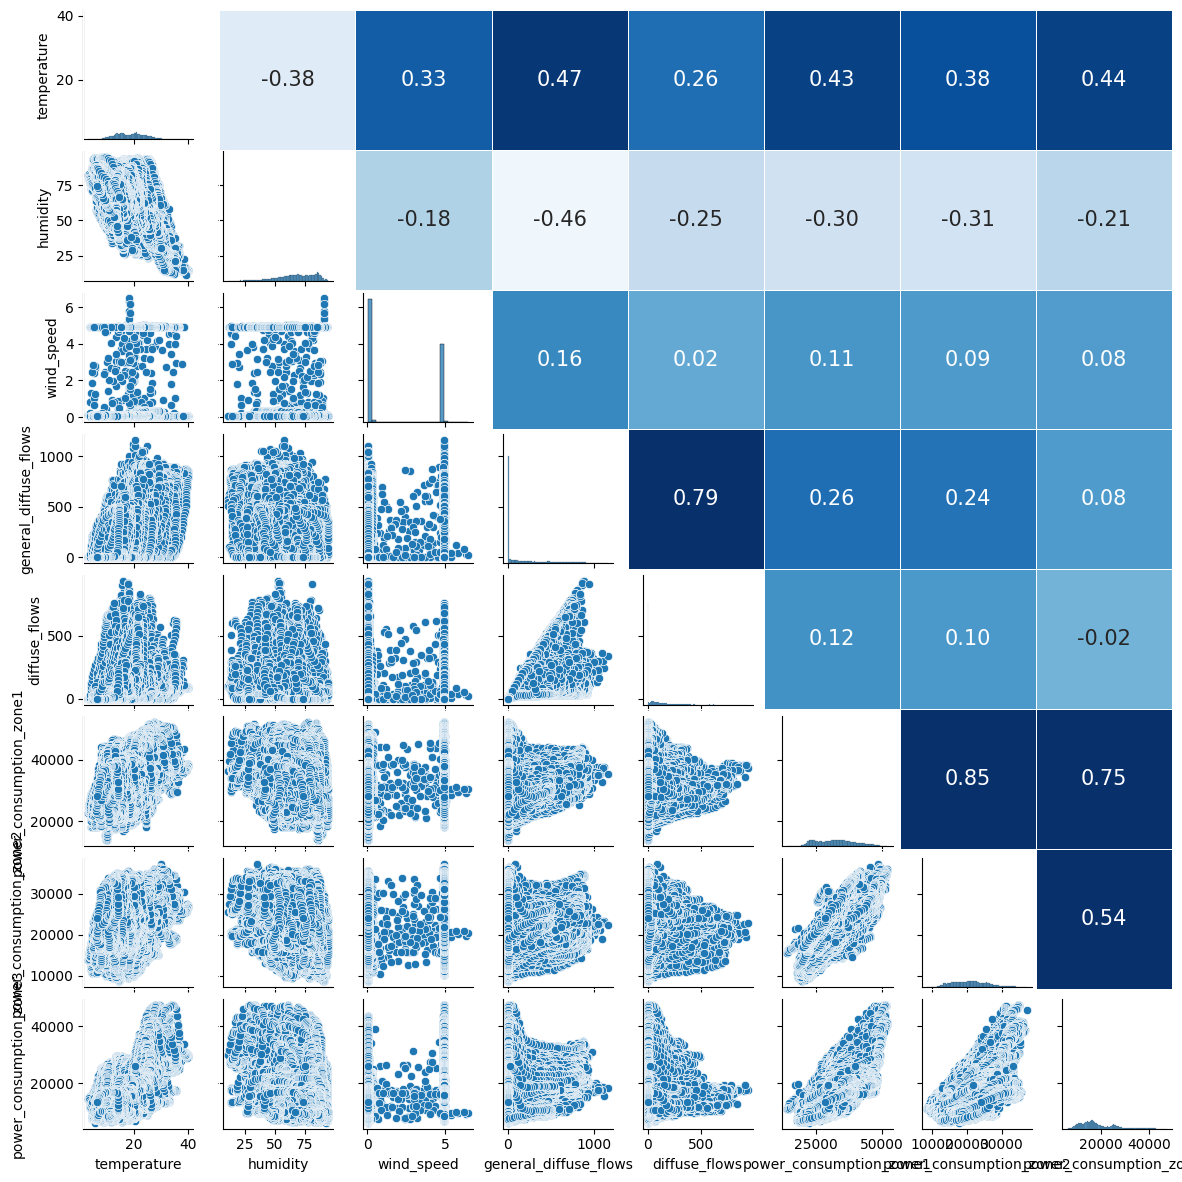

In [14]:
def hide_axis(*args, **kwds):
    plt.gca().set_visible(False)

correlacion = file_input.select_dtypes(include=np.number).corr(method="spearman")
CorrPair = sns.pairplot(file_input.select_dtypes(include=np.number), height=1.5)
CorrPair.map_upper(hide_axis)

(xmin, _), (_, ymax) = CorrPair.axes[0, 0].get_position().get_points()
(_, ymin), (xmax, _) = CorrPair.axes[-1, -1].get_position().get_points()

ax = CorrPair.fig.add_axes([xmin, ymin, xmax - xmin, ymax - ymin], facecolor='none')

mask1 = np.tril(np.ones_like(correlacion, dtype=bool))
sns.heatmap(correlacion, mask=mask1,
            cmap='Blues', vmax=.5, vmin=-.5, fmt=".2f",
            linewidths=.5, cbar=False, annot=True, annot_kws={'size': 15}, ax=ax)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

#### 2. Ahora procedemos con la transformación de los datos generando columnas nuevas

La fecha será la primera en aplicar una transformación que permitirá una mejor visualización y segmentación de los datos, además incluiremos una columna con la temporada de clima que aunque en Marruecos no son extremos, si se presentan variaciones en las temperaturas, esto permitiría un análisis de consumo por temporada.

In [15]:
def obtener_temporada_marruecos(fecha):
    año = fecha.year    
    # Definir fechas de estaciones en Marruecos
    primavera = pd.Timestamp(f"{año}-03-21")
    verano = pd.Timestamp(f"{año}-06-21")
    otoño = pd.Timestamp(f"{año}-09-21")
    invierno = pd.Timestamp(f"{año}-12-21")

    # Asignar temporada según la fecha
    if primavera <= fecha < verano:
        return 'Primavera'
    elif verano <= fecha < otoño:
        return 'Verano'
    elif otoño <= fecha < invierno:
        return 'Otoño'
    else:
        return 'Invierno'

file_input['season'] = file_input['datetime'].apply(obtener_temporada_marruecos)

In [16]:
valores_unicos = file_input['season'].value_counts()
print(valores_unicos)

season
Primavera    13248
Verano       13248
Otoño        13104
Invierno     12816
Name: count, dtype: int64


In [17]:
file_input['year'] = file_input['datetime'].dt.year
file_input['month'] = file_input['datetime'].dt.month
file_input['day'] = file_input['datetime'].dt.day
file_input['hour'] = file_input['datetime'].dt.hour
file_input['minute'] = file_input['datetime'].dt.minute
file_input['day_name'] = file_input['datetime'].dt.day_name()

Cambio nuevamente del formato fecha a consecutivo numérico

In [18]:
file_input["datetime"] = file_input["datetime"].dt.strftime("%Y%m%d%H%M").astype(int)

In [19]:
file_input

,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,power_consumption_zone1,power_consumption_zone2,power_consumption_zone3,season,year,month,day,hour,minute,day_name
0,201701010000,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,Invierno,2017,1,1,0,0,Sunday
1,201701010010,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,Invierno,2017,1,1,0,10,Sunday
2,201701010020,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,Invierno,2017,1,1,0,20,Sunday
3,201701010030,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,Invierno,2017,1,1,0,30,Sunday
4,201701010040,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,Invierno,2017,1,1,0,40,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52411,201712302310,7.010,72.4,0.080,0.040,0.096,31160.45627,26857.31820,14780.31212,Invierno,2017,12,30,23,10,Saturday
52412,201712302320,6.947,72.6,0.082,0.051,0.093,30430.41825,26124.57809,14428.81152,Invierno,2017,12,30,23,20,Saturday
52413,201712302330,6.900,72.8,0.086,0.084,0.074,29590.87452,25277.69254,13806.48259,Invierno,2017,12,30,23,30,Saturday
52414,201712302340,6.758,73.0,0.080,0.066,0.089,28958.17490,24692.23688,13512.60504,Invierno,2017,12,30,23,40,Saturday


Aunque con las variables temperatura y humedad relativa se podrían calcular otras como la humedad absoluta, el punto de rocío e incluso la sensacion térmica, vamos a conservarlas sin transformaciones, pues teniendo en cuenta el objetivo principal de predicción de consumo, las variables ambientales suelen tener una relación directa con el comportamiento de consumo energético.

La velocidad del viento, a pesar de no tener una correlación directa con las variables de consumo, la podemos utilizar para calcular la potencia eólico asumiendo algunos valores de referencia de generadores eólicos comunes, la fórmula es la siguiente: $$ P = \frac{1}{2} \rho A v^3 C_p $$

Las unidades de la velocidad del viento en la tabla 

### Donde:

- \( P \) = Potencia en vatios (**W**).
- \( \rho \) = Densidad del aire a nivel del mar.:

  $$ \rho \approx 1.225 \, \text{kg/m}^3 $$

- \( A \) = Área barrida por las aspas en \( m^2 \):

  $$ A = \pi r^2 $$

- \( v \) = Velocidad del viento en **m/s**.

- \( C_p \) = Coeficiente de potencia del aerogenerador típicamente entre **0.35 - 0.45** en turbinas comerciales.




In [20]:
# Parámetros del aerogenerador
air_density = 1.225  # kg/m³ (a nivel del mar)
radius = 20  # Radio de las aspas en metros
swept_area = np.pi * radius**2  # Área barrida en m²
power_coefficient = 0.4  # Coeficiente de potencia típico

file_input["wind_power_kwatts"] = 0.5 * air_density * swept_area * ((file_input["wind_speed"]*100) ** 3) * power_coefficient/1000

La nueva columna wind_power_watts representa el potencial de generación eléctrica de 1 unidad, esto es importante a tener encuenta en escenarios futuros.

Borraremos la columna wind_speed pues ya no representa interés para el ejercicio

In [21]:
file_input = file_input.drop(['wind_speed'], axis=1)

Es posible crear un índice de irradiación solar efectiva combinando general_diffuse_flows y diffuse_flows porque ambos representan componentes clave de la radiación solar que impactan en la generación de energía fotovoltaica y posteriormente calcular la potencia generada por un panel solar convencional. Al igual que el ejercicio anterior con el viento, transformaremos estas variables en capacidad de generación solar y así planificar escenarios de oferta de energía con fuentes renovables.

$$ \text{Índice} = w_1 \cdot G_b + w_2 \cdot G_d $$


Donde w1 y w2 son pesos que dependen de la eficiencia de los paneles solares para aprovechar cada tipo de radiación.

$$ P_{PV} = \eta \cdot A \cdot \text{Índice} $$


### Parámetros:

- \( \eta \) = Eficiencia del sistema solar (**típicamente entre 15% y 22%** para paneles comerciales).  
- \( A \) = Área total del sistema fotovoltaico en \( m^2 \).  
- **Índice** = Índice de Irradiación Solar Efectiva en \( W/m^2 \)  
  *(calculado previamente como combinación de* `general_diffuse_flows` *y* `diffuse_flows`*).*  


In [22]:
# Definir pesos (ajustar según eficiencia del sistema)
w1 = 0.6  # Peso para la radiación directa
w2 = 0.4  # Peso para la radiación difusa
# Parámetros del sistema solar
panel_efficiency = 0.20  # 18% eficiencia típica
panel_area = 2  # m² (ejemplo con un sistema pequeño)

# Calcular el potencial de generación eléctrica (kW)
file_input["solar_power_kwatts"] = panel_efficiency * panel_area * ((w1 * (file_input["general_diffuse_flows"]*1000)) + (w2 * file_input["diffuse_flows"]*1000))/100


In [23]:
file_input = file_input.drop(['general_diffuse_flows','diffuse_flows'], axis=1)

Finalmente con las potencias podemos realizar una primera transformación correspondiente a la sumatoria para conocer la demanda total del sistema eléctrico, así como convertir estos valores en sus equivalencias de energía que es la base principal de las transacciones eléctricas.
Por otra parte, la potencia instantánea puede ser de utilidad para proponer escenarios de capacidad instalada, pues los picos de consumo son los que estresan el sistema eléctrico y con la energía no es posible detectar estas condiciones.
Teniendo en cuenta esto, conservaremos las potencias adicionando la total y así mismo tendremos sus equivalencias en energía.

In [24]:
file_input['power_consumption_total'] = file_input[['power_consumption_zone1', 'power_consumption_zone2', 'power_consumption_zone3']].sum(axis=1)

Como las muestras están cada 10 minutos, referenciaremos la energía a esta escala de tiempo (6 muestras por hora, cada muestra equivale a una sexta parte de la hora) para futuros ejercicios de acumulados horarios

In [25]:
file_input['energy_consumption_zone1'] = file_input['power_consumption_zone1']/6
file_input['energy_consumption_zone2'] = file_input['power_consumption_zone2']/6
file_input['energy_consumption_zone3'] = file_input['power_consumption_zone3']/6
file_input['energy_consumption_total'] = file_input['power_consumption_total']/6

El dataset finalmente quedaría de la siguiente manera:

In [26]:
file_input.head()

,datetime,temperature,humidity,power_consumption_zone1,power_consumption_zone2,power_consumption_zone3,season,year,month,day,hour,minute,day_name,wind_power_kwatts,solar_power_kwatts,power_consumption_total,energy_consumption_zone1,energy_consumption_zone2,energy_consumption_zone3,energy_consumption_total
0,201701010000,6.559,73.8,34055.69620,16128.87538,20240.96386,Invierno,2017,1,1,0,0,Sunday,176.039540,0.3128,70425.53544,5675.949367,2688.145897,3373.493977,11737.589240
1,201701010010,6.414,74.5,29814.68354,19375.07599,20131.08434,Invierno,2017,1,1,0,10,Sunday,176.039540,0.3040,69320.84387,4969.113923,3229.179332,3355.180723,11553.473978
2,201701010020,6.313,74.5,29128.10127,19006.68693,19668.43373,Invierno,2017,1,1,0,20,Sunday,157.632553,0.3088,67803.22193,4854.683545,3167.781155,3278.072288,11300.536988
3,201701010030,6.121,75.0,28228.86076,18361.09422,18899.27711,Invierno,2017,1,1,0,30,Sunday,176.039540,0.3720,65489.23209,4704.810127,3060.182370,3149.879518,10914.872015
4,201701010040,5.921,75.7,27335.69620,17872.34043,18442.40964,Invierno,2017,1,1,0,40,Sunday,163.617972,0.2512,63650.44627,4555.949367,2978.723405,3073.734940,10608.407712


Ahora ejecutaremos el etl desarrollado hasta el momento, en el cual ya se encuentra incorporada la sección de transformación que desarrollamos en este notebook

In [31]:
file_transformado = etl.etl_full()

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption
Conexión exitosa
La base de datos 'project1_db' ya existe.
Datos cargados en la base de datos exitosamente.
Dataset almacenado en área de staging existosamente
Dataset cargado desde el área de staging
Transformaciones realizadas exitosamente!


In [32]:
file_transformado.head()

,datetime,temperature,humidity,power_consumption_zone1,power_consumption_zone2,power_consumption_zone3,season,year,month,day,hour,minute,day_name,wind_power_kwatts,solar_power_kwatts,power_consumption_total,energy_consumption_zone1,energy_consumption_zone2,energy_consumption_zone3,energy_consumption_total
0,201701010000,6.559,73.8,34055.69620,16128.87538,20240.96386,Invierno,2017,1,1,0,0,Sunday,176.039540,0.3128,70425.53544,5675.949367,2688.145897,3373.493977,11737.589240
1,201701010010,6.414,74.5,29814.68354,19375.07599,20131.08434,Invierno,2017,1,1,0,10,Sunday,176.039540,0.3040,69320.84387,4969.113923,3229.179332,3355.180723,11553.473978
2,201701010020,6.313,74.5,29128.10127,19006.68693,19668.43373,Invierno,2017,1,1,0,20,Sunday,157.632553,0.3088,67803.22193,4854.683545,3167.781155,3278.072288,11300.536988
3,201701010030,6.121,75.0,28228.86076,18361.09422,18899.27711,Invierno,2017,1,1,0,30,Sunday,176.039540,0.3720,65489.23209,4704.810127,3060.182370,3149.879518,10914.872015
4,201701010040,5.921,75.7,27335.69620,17872.34043,18442.40964,Invierno,2017,1,1,0,40,Sunday,163.617972,0.2512,63650.44627,4555.949367,2978.723405,3073.734940,10608.407712


In [29]:
if file_input.equals(file_transformado):
    print("Los DataFrames son exactamente iguales")
else:
    print("Los DataFrames son diferentes")

Los DataFrames son exactamente iguales


El dataframe resultante (file_transformado) es el mismo que obtuvimos al final del notebook (file_input) con esto validamos que quedaron bien implementadas las funciones de transformación

In [30]:
file_transformado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   datetime                  52416 non-null  int64  
 1   temperature               52416 non-null  float64
 2   humidity                  52416 non-null  float64
 3   power_consumption_zone1   52416 non-null  float64
 4   power_consumption_zone2   52416 non-null  float64
 5   power_consumption_zone3   52416 non-null  float64
 6   season                    52416 non-null  object 
 7   year                      52416 non-null  int32  
 8   month                     52416 non-null  int32  
 9   day                       52416 non-null  int32  
 10  hour                      52416 non-null  int32  
 11  minute                    52416 non-null  int32  
 12  day_name                  52416 non-null  object 
 13  wind_power_kwatts         52416 non-null  float64
 14  solar_

In [3]:
etl.borrar_tablas()

Conexión exitosa
✅ Tablas eliminadas correctamente.
🔒 Conexión cerrada correctamente.


In [2]:
file_transformado = etl.etl_full()

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption
Conexión exitosa
La base de datos 'project1_db' ya existe.
Datos cargados en la base de datos exitosamente.
Dataset almacenado en área de staging existosamente
Dataset cargado desde el área de staging
Transformaciones realizadas exitosamente!
Hola Tilín 2
Dataset cargado en bd modelo dimensional
   time_key            datetime  year  month  day  hour  minute day_name  \
0         1 2017-01-01 00:00:00  2017      1    1     0       0   Sunday   
1         2 2017-01-01 00:10:00  2017      1    1     0      10   Sunday   
2         3 2017-01-01 00:20:00  2017      1    1     0      20   Sunday   
3         4 2017-01-01 00:30:00  2017      1    1     0      30   Sunday   
4         5 2017-01-01 00:40:00  2017      1    1     0      40   Sunday   

     season  
0  Invierno  
1  Invierno  
2  Invierno  
3  Invierno  
4  Invierno  
   weather_key  temperature  humidity
0            1        6.559      73.8
1 

In [4]:
file_transformado = etl.etl_full()

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption
Conexión exitosa
La base de datos 'project1_db' ya existe.
No hay datos nuevos. El proceso de ETL no se ejecuta.
ETL No ejecutado porque no hay datos nuevos
